# Descriptive statistics

This notebook uses the Adult Income dataset (`adult.data` and `adult.test`) and demonstrates various descriptive statistics.

At the end, the cleaned and the encoded data are saved to the `cleaned_data` folder, so the other notebooks can use them.

## Getting ready

Import libraries.

In [1]:
import os
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

print("Libraries loaded.")

Libraries loaded.


## Load the data and inspect its structure

In [2]:
column_names = ["age", "workclass", "fnlwgt", "education", "education-num", "marital-status", "occupation", "relationship", "race", "sex", "capital-gain", "capital-loss", "hours-per-week", "native-country", "income"]

train = pd.read_csv("../active_dataset(adult_income)/adult.data",
                    names=column_names,
                    na_values="?",
                    skipinitialspace=True,
                    header=None)

# The first line of adult.test is a comment, so it is skipped
test = pd.read_csv("../active_dataset(adult_income)/adult.test",
                   names=column_names,
                   na_values="?",
                   skipinitialspace=True,
                   header=None,
                   skiprows=1)

df = pd.concat([train, test], ignore_index=True)

# The test file writes income as ">50K." and "<=50K." - remove the dot
df["income"] = df["income"].str.replace(".", "", regex=False)

df_original = df.copy()

# Delete rows with missing values
df = df.dropna()
df = df.reset_index(drop=True)

# Display the first five observations
display(df.head())

# Dataset dimensions
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print(f"Dataset shape before deleting missing values: {df_original.shape}")
print(f"Dataset shape: {df.shape}")
print("Number of observations:", df.shape[0])
print("Number of variables:", df.shape[1])

# Variable names and data types
print("\nVariable information:")
df.info()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


Train shape: (32561, 15)
Test shape: (16281, 15)
Dataset shape before deleting missing values: (48842, 15)
Dataset shape: (45222, 15)
Number of observations: 45222
Number of variables: 15

Variable information:
<class 'pandas.DataFrame'>
RangeIndex: 45222 entries, 0 to 45221
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             45222 non-null  int64
 1   workclass       45222 non-null  str  
 2   fnlwgt          45222 non-null  int64
 3   education       45222 non-null  str  
 4   education-num   45222 non-null  int64
 5   marital-status  45222 non-null  str  
 6   occupation      45222 non-null  str  
 7   relationship    45222 non-null  str  
 8   race            45222 non-null  str  
 9   sex             45222 non-null  str  
 10  capital-gain    45222 non-null  int64
 11  capital-loss    45222 non-null  int64
 12  hours-per-week  45222 non-null  int64
 13  native-country  45222 non-null  str  
 14

#### Check for missing values

In [3]:
missing_values = pd.DataFrame({
    "Missing values": df_original.isna().sum(),
    "Missing percentage (%)": df_original.isna().mean() * 100
})

display(missing_values)

,Missing values,Missing percentage (%)
age,0,0.000000
workclass,2799,5.730724
fnlwgt,0,0.000000
education,0,0.000000
education-num,0,0.000000
marital-status,0,0.000000
occupation,2809,5.751198
relationship,0,0.000000
race,0,0.000000
sex,0,0.000000


Missing values are only in `workclass` (5.73%), `occupation` (5.75%) and `native-country` (1.75%). 3,620 rows (7.41%) have at least one missing value.

We deleted these rows in the loading cell. There are still more than 45,000 rows left, which is enough for the analysis.

The deleted rows are not random: people with missing values earn >50K less often (13.2%) than the others (24.8%). So after deleting, people with higher income are a bit overrepresented.

#### Check for duplicate rows

In [4]:
# Number of rows that are an exact copy of an earlier row
print("Duplicate rows:", df.duplicated().sum())

# Show the duplicated rows together with their copies
duplicate_rows = df[df.duplicated(keep=False)]
display(duplicate_rows.sort_values(by=list(df.columns)).head(10))

Duplicate rows:

 47


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
22869,17,Private,153021,12th,8,Never-married,Sales,Own-child,White,Female,0,0,20,United-States,<=50K
34011,17,Private,153021,12th,8,Never-married,Sales,Own-child,White,Female,0,0,20,United-States,<=50K
33777,18,Self-emp-inc,378036,12th,8,Never-married,Farming-fishing,Own-child,White,Male,0,0,10,United-States,<=50K
44918,18,Self-emp-inc,378036,12th,8,Never-married,Farming-fishing,Own-child,White,Male,0,0,10,United-States,<=50K
16376,19,Private,97261,HS-grad,9,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,40,United-States,<=50K
17329,19,Private,97261,HS-grad,9,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,40,United-States,<=50K
2864,19,Private,130431,5th-6th,3,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,36,Mexico,<=50K
31701,19,Private,130431,5th-6th,3,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,36,Mexico,<=50K
6445,19,Private,138153,Some-college,10,Never-married,Adm-clerical,Own-child,White,Female,0,0,10,United-States,<=50K
19753,19,Private,138153,Some-college,10,Never-married,Adm-clerical,Own-child,White,Female,0,0,10,United-States,<=50K


#### Delete duplicate rows

Only the first occurrence of each row is kept.

In [5]:
print("Rows before:", len(df))

df = df.drop_duplicates()
df = df.reset_index(drop=True)

print("Rows after:", len(df))
print("Duplicate rows left:", df.duplicated().sum())

Rows before: 45222


Rows after: 45175
Duplicate rows left: 0


## Descriptive statistics

#### Descriptive statistics for numerical variables

In [6]:
numeric_columns = [ "age",
    "fnlwgt",
    "education-num",
    "capital-gain",
    "capital-loss",
    "hours-per-week"
]

# Basic descriptive statistics
numeric_statistics = df[numeric_columns].describe().T

display(numeric_statistics)

,count,mean,std,min,25%,50%,75%,max
age,45175.0,38.556170,13.215349,17.0,28.0,37.0,47.0,90.0
fnlwgt,45175.0,189738.798450,105652.436515,13492.0,117392.5,178312.0,237903.0,1490400.0
education-num,45175.0,10.119314,2.551740,1.0,9.0,10.0,13.0,16.0
capital-gain,45175.0,1102.576270,7510.249876,0.0,0.0,0.0,0.0,99999.0
capital-loss,45175.0,88.687593,405.156611,0.0,0.0,0.0,0.0,4356.0
hours-per-week,45175.0,40.942512,12.007730,1.0,40.0,40.0,45.0,99.0


#### More detailed descriptive statistics

In [7]:
descriptive_statistics = []

for column in numeric_columns:

    data = pd.to_numeric(df[column], errors="coerce").dropna()

    # Mode
    mode_values = data.mode()

    # If there is more than one mode, display all modes
    if len(mode_values) == 1:
        mode = mode_values.iloc[0]
    else:
        mode = ", ".join(
            [f"{value:.4f}" for value in mode_values]
        )

    # Quartiles
    q1 = data.quantile(0.25)
    median = data.quantile(0.50)
    q3 = data.quantile(0.75)

    # Minimum and maximum
    minimum = data.min()
    maximum = data.max()

    # Range and interquartile range
    data_range = maximum - minimum
    iqr = q3 - q1

    # Add results
    descriptive_statistics.append({
        "Variable": column,
        "Mean": data.mean(),
        "Median": median,
        "Mode": mode,
        "Minimum": minimum,
        "Q1 (25%)": q1,
        "Q2 (50%)": median,
        "Q3 (75%)": q3,
        "Maximum": maximum,
        "Range": data_range,
        "Interquartile Range (IQR)": iqr,
        "Variance": data.var(),
        "Standard Deviation": data.std(),
        "Skewness": data.skew(),
        "Kurtosis": data.kurt()
    })

# Create the summary table
descriptive_statistics = pd.DataFrame(descriptive_statistics)

# Display the results
display(descriptive_statistics)

,Variable,Mean,Median,Mode,Minimum,Q1 (25%),Q2 (50%),Q3 (75%),Maximum,Range,Interquartile Range (IQR),Variance,Standard Deviation,Skewness,Kurtosis
0,age,38.556170,37.0,36,17,28.0,37.0,47.0,90,73,19.0,1.746454e+02,13.215349,0.531796,-0.158989
1,fnlwgt,189738.798450,178312.0,203488,13492,117392.5,178312.0,237903.0,1490400,1476908,120510.5,1.116244e+10,105652.436515,1.448304,6.187641
2,education-num,10.119314,10.0,9,1,9.0,10.0,13.0,16,15,4.0,6.511376e+00,2.551740,-0.308033,0.630116
3,capital-gain,1102.576270,0.0,0,0,0.0,0.0,0.0,99999,99999,0.0,5.640385e+07,7510.249876,11.782816,149.991798
4,capital-loss,88.687593,0.0,0,0,0.0,0.0,0.0,4356,4356,0.0,1.641519e+05,405.156611,4.513622,19.338843
5,hours-per-week,40.942512,40.0,40,1,40.0,40.0,45.0,99,98,5.0,1.441856e+02,12.007730,0.341760,3.201876


#### Frequency tables for categorical variables

In [8]:
categorical_columns = [
    "workclass",
    "education",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "native-country"
]

for column in categorical_columns:

    print("\n" + "=" * 60)
    print(f"{column}")
    print("=" * 60)

    frequency_table = df[column].value_counts(dropna=False).to_frame(
        name="Frequency"
    )

    frequency_table["Percentage (%)"] = (
        frequency_table["Frequency"] / len(df) * 100
    )

    display(frequency_table)


workclass


,Frequency,Percentage (%)
workclass,,
Private,33262,73.629220
Self-emp-not-inc,3795,8.400664
Local-gov,3100,6.862203
State-gov,1946,4.307692
Self-emp-inc,1645,3.641395
Federal-gov,1406,3.112341
Without-pay,21,0.046486



education


,Frequency,Percentage (%)
education,,
HS-grad,14770,32.695075
Some-college,9887,21.885999
Bachelors,7559,16.732706
Masters,2513,5.562811
Assoc-voc,1958,4.334256
11th,1619,3.583841
Assoc-acdm,1507,3.335916
10th,1223,2.707250
7th-8th,822,1.819590



marital-status


...

,Frequency,Percentage (%)
race,,
White,38859,86.018816
Black,4227,9.356945
Asian-Pac-Islander,1301,2.879911
Amer-Indian-Eskimo,435,0.962922
Other,353,0.781406



sex


,Frequency,Percentage (%)
sex,,
Male,30495,67.504151
Female,14680,32.495849



native-country


,Frequency,Percentage (%)
native-country,,
United-States,41256,91.324848
Mexico,895,1.981184
Philippines,282,0.624239
Germany,193,0.427227
Puerto-Rico,175,0.387382
Canada,163,0.360819
India,147,0.325401
El-Salvador,147,0.325401
Cuba,133,0.294411


#### Cross tabulations (Crosstabs)

In [9]:
crosstab_pairs = [
    ("education", "income"),
    ("marital-status", "income"),
    ("relationship", "income")
]

for row_variable, column_variable in crosstab_pairs:

    print("\n" + "=" * 70)
    print(
        f"Crosstab (frequencies): {row_variable} × {column_variable}"
    )
    print("=" * 70)

    crosstab = pd.crosstab(
        df[row_variable],
        df[column_variable]
    )

    display(crosstab)

    print("\n" + "=" * 70)
    print(
        f"Crosstab (total percentages): {row_variable} × {column_variable}"
    )
    print("=" * 70)

    crosstab_total_percent = pd.crosstab(
        df[row_variable],
        df[column_variable],
        normalize="all"
    ) * 100

    display(crosstab_total_percent.round(2))



Crosstab (frequencies): education × income


income,<=50K,>50K
education,,
10th,1141,82
11th,1530,89
12th,532,43
1st-4th,212,8
5th-6th,425,22
7th-8th,767,55
9th,638,38
Assoc-acdm,1109,398
Assoc-voc,1454,504



Crosstab (total percentages): education × income


income,<=50K,>50K
education,,
10th,2.53,0.18
11th,3.39,0.20
12th,1.18,0.10
1st-4th,0.47,0.02
5th-6th,0.94,0.05
7th-8th,1.70,0.12
9th,1.41,0.08
Assoc-acdm,2.45,0.88
Assoc-voc,3.22,1.12



Crosstab (frequencies): marital-status × income


...

income,<=50K,>50K
marital-status,,
Divorced,12.48,1.45
Married-AF-spouse,0.04,0.03
Married-civ-spouse,25.42,21.16
Married-spouse-absent,1.10,0.12
Never-married,30.69,1.55
Separated,2.90,0.22
Widowed,2.56,0.27



Crosstab (frequencies): relationship × income


income,<=50K,>50K
relationship,,
Husband,10152,8501
Not-in-family,10451,1228
Other-relative,1299,50
Own-child,6511,105
Unmarried,4485,302
Wife,1075,1016



Crosstab (total percentages): relationship × income


income,<=50K,>50K
relationship,,
Husband,22.47,18.82
Not-in-family,23.13,2.72
Other-relative,2.88,0.11
Own-child,14.41,0.23
Unmarried,9.93,0.67
Wife,2.38,2.25


#### z-scores

In [10]:
# Calculate z-scores for all numerical variables

z_scores = pd.DataFrame(
    stats.zscore(
        df[numeric_columns],
        nan_policy="omit"
    ),
    columns=numeric_columns,
    index=df.index
)

print("z-scores for the numerical variables:")
display(z_scores.head())


# z-scores summary

z_score_summary = pd.DataFrame({
    "Variable": numeric_columns,
    "Mean of z-scores": [
        z_scores[column].mean()
        for column in numeric_columns
    ],
    "Std of z-scores": [
        z_scores[column].std()
        for column in numeric_columns
    ],
    "Minimum z-score": [
        z_scores[column].min()
        for column in numeric_columns
    ],
    "Maximum z-score": [
        z_scores[column].max()
        for column in numeric_columns
    ]
})

display(z_score_summary.round(4))

z-scores for the numerical variables:


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
0,0.033585,-1.062200,1.128923,0.142663,-0.218899,-0.078493
1,0.865959,-1.007350,1.128923,-0.146811,-0.218899,-2.327069
2,-0.042086,0.245214,-0.438652,-0.146811,-0.218899,-0.078493
3,1.092971,0.425761,-1.222440,-0.146811,-0.218899,-0.078493
4,-0.798790,1.407179,1.128923,-0.146811,-0.218899,-0.078493


,Variable,Mean of z-scores,Std of z-scores,Minimum z-score,Maximum z-score
0,age,0.0,1.0,-1.6312,3.8928
1,fnlwgt,-0.0,1.0,-1.6682,12.3109
2,education-num,-0.0,1.0,-3.5738,2.3046
3,capital-gain,-0.0,1.0,-0.1468,13.1683
4,capital-loss,0.0,1.0,-0.2189,10.5326
5,hours-per-week,-0.0,1.0,-3.3264,4.8351


#### Detecting outliers using z-scores

In [11]:
Z_THRESHOLD = 3

z_outlier_flags = pd.DataFrame(
    False,
    index=df.index,
    columns=numeric_columns
)

for column in numeric_columns:
    z_outlier_flags[column] = z_scores[column].abs() > Z_THRESHOLD

# Number of potential outliers for each variable
z_outlier_summary = pd.DataFrame({
    "Variable": numeric_columns,
    "Potential outliers": [
        z_outlier_flags[column].sum()
        for column in numeric_columns
    ]
})

z_outlier_summary["Percentage (%)"] = (
    z_outlier_summary["Potential outliers"]
    / len(df) * 100
)

display(z_outlier_summary.round(2))


# z-score outlier observations

for column in numeric_columns:

    outlier_indices = z_outlier_flags.index[
        z_outlier_flags[column]
    ]

    if len(outlier_indices) > 0:

        print("\n" + "=" * 70)
        print(f"z-score outliers: {column}")
        print("=" * 70)

        outlier_table = df.loc[
            outlier_indices,
            ["income", column]
        ].copy()

        outlier_table["z-score"] = z_scores.loc[
            outlier_indices,
            column
        ]

        display(
            outlier_table.sort_values(
                "z-score"
            )
        )

    else:

        print(
            f"\n{column}: No observations with |z| > {Z_THRESHOLD}."
        )

,Variable,Potential outliers,Percentage (%)
0,age,162,0.36
1,fnlwgt,471,1.04
2,education-num,290,0.64
3,capital-gain,310,0.69
4,capital-loss,2077,4.60
5,hours-per-week,626,1.39



z-score outliers: age


,income,age,z-score
68,<=50K,79,3.060402
4323,<=50K,79,3.060402
5673,>50K,79,3.060402
5507,<=50K,79,3.060402
7863,<=50K,79,3.060402
...,...,...,...
41646,<=50K,90,3.892776
38436,<=50K,90,3.892776
37919,<=50K,90,3.892776
44082,>50K,90,3.892776



z-score outliers: fnlwgt


,income,fnlwgt,z-score
26466,<=50K,506830,3.001301
41517,<=50K,506830,3.001301
6120,>50K,506858,3.001566
41923,<=50K,507492,3.007566
37,<=50K,507875,3.011192
...,...,...,...
14418,<=50K,1268339,10.209061
15497,<=50K,1366120,11.134568
16809,<=50K,1455435,11.979943
13375,<=50K,1484705,12.256987


...

,income,capital-gain,z-score
38638,>50K,25124,3.198521
20800,>50K,25124,3.198521
44460,>50K,25124,3.198521
17463,>50K,25124,3.198521
6068,>50K,25236,3.213434
...,...,...,...
3524,>50K,99999,13.168339
44940,>50K,99999,13.168339
44970,>50K,99999,13.168339
1256,>50K,99999,13.168339



z-score outliers: capital-loss


,income,capital-loss,z-score
188,<=50K,1340,3.088500
1396,<=50K,1340,3.088500
36345,<=50K,1340,3.088500
38551,<=50K,1340,3.088500
19327,<=50K,1340,3.088500
...,...,...,...
38729,<=50K,3770,9.086247
10998,<=50K,3770,9.086247
18912,<=50K,3900,9.407114
22043,<=50K,3900,9.407114



z-score outliers: hours-per-week


,income,hours-per-week,z-score
23226,<=50K,1,-3.326437
40460,>50K,1,-3.326437
22494,<=50K,1,-3.326437
39778,<=50K,1,-3.326437
21263,<=50K,1,-3.326437
...,...,...,...
24064,<=50K,99,4.835063
24311,<=50K,99,4.835063
24627,>50K,99,4.835063
24666,<=50K,99,4.835063


#### Detecting outliers using the IQR method

In [12]:
iqr_outlier_flags = pd.DataFrame(
    False,
    index=df.index,
    columns=numeric_columns
)

iqr_summary = []

for column in numeric_columns:

    data = pd.to_numeric(
        df[column],
        errors="coerce"
    )

    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    flags = (
        (data < lower_bound) |
        (data > upper_bound)
    )

    iqr_outlier_flags[column] = flags

    iqr_summary.append({
        "Variable": column,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower bound": lower_bound,
        "Upper bound": upper_bound,
        "Potential outliers": flags.sum(),
        "Percentage (%)": flags.mean() * 100
    })

iqr_summary = pd.DataFrame(iqr_summary)

display(iqr_summary.round(4))


# IQR outlier observations

for column in numeric_columns:

    outlier_indices = iqr_outlier_flags.index[
        iqr_outlier_flags[column]
    ]

    if len(outlier_indices) > 0:

        print("\n" + "=" * 70)
        print(f"IQR outliers: {column}")
        print("=" * 70)

        outlier_table = df.loc[
            outlier_indices,
            ["income", column]
        ].copy()

        display(
            outlier_table.sort_values(
                by=column
            )
        )

    else:

        print(
            f"\n{column}: No IQR outliers detected."
        )

,Variable,Q1,Q3,IQR,Lower bound,Upper bound,Potential outliers,Percentage (%)
0,age,28.0,47.0,19.0,-0.50,75.50,268,0.5932
1,fnlwgt,117392.5,237903.0,120510.5,-63373.25,418668.75,1332,2.9485
2,education-num,9.0,13.0,4.0,3.00,19.00,290,0.6419
3,capital-gain,0.0,0.0,0.0,0.00,0.00,3790,8.3896
4,capital-loss,0.0,0.0,0.0,0.00,0.00,2140,4.7371
5,hours-per-week,40.0,45.0,5.0,32.50,52.50,11889,26.3177



IQR outliers: age


,income,age
43794,<=50K,76
92,>50K,76
3334,<=50K,76
3848,<=50K,76
4357,<=50K,76
...,...,...
4919,>50K,90
4951,>50K,90
3734,<=50K,90
44082,>50K,90



IQR outliers: fnlwgt


,income,fnlwgt
29238,<=50K,418702
32685,<=50K,418901
20442,<=50K,418961
13261,<=50K,419053
25588,<=50K,419134
...,...,...
14418,<=50K,1268339
15497,<=50K,1366120
16809,<=50K,1455435
13375,<=50K,1484705


...

,income,capital-gain
30528,<=50K,114
21887,<=50K,114
5766,<=50K,114
38650,<=50K,114
21129,<=50K,114
...,...,...
13981,>50K,99999
13726,>50K,99999
44970,>50K,99999
44935,>50K,99999



IQR outliers: capital-loss


,income,capital-loss
18774,<=50K,155
3367,<=50K,213
10424,<=50K,213
16001,<=50K,213
38803,<=50K,213
...,...,...
41950,<=50K,3770
38729,<=50K,3770
18912,<=50K,3900
22043,<=50K,3900



IQR outliers: hours-per-week


,income,hours-per-week
175,>50K,1
23226,<=50K,1
39778,<=50K,1
10580,<=50K,1
21263,<=50K,1
...,...,...
21044,>50K,99
41355,<=50K,99
16313,<=50K,99
24311,<=50K,99


#### Compare the two outlier-detection methods

In [13]:
outlier_comparison = pd.DataFrame({
    "Variable": numeric_columns,
    "z-score outliers": [
        z_outlier_flags[column].sum()
        for column in numeric_columns
    ],
    "IQR outliers": [
        iqr_outlier_flags[column].sum()
        for column in numeric_columns
    ]
})

outlier_comparison["Difference"] = (
    outlier_comparison["z-score outliers"]
    - outlier_comparison["IQR outliers"]
)

display(outlier_comparison)

,Variable,z-score outliers,IQR outliers,Difference
0,age,162,268,-106
1,fnlwgt,471,1332,-861
2,education-num,290,290,0
3,capital-gain,310,3790,-3480
4,capital-loss,2077,2140,-63
5,hours-per-week,626,11889,-11263


#### Box-and-whisker diagram (boxplot)

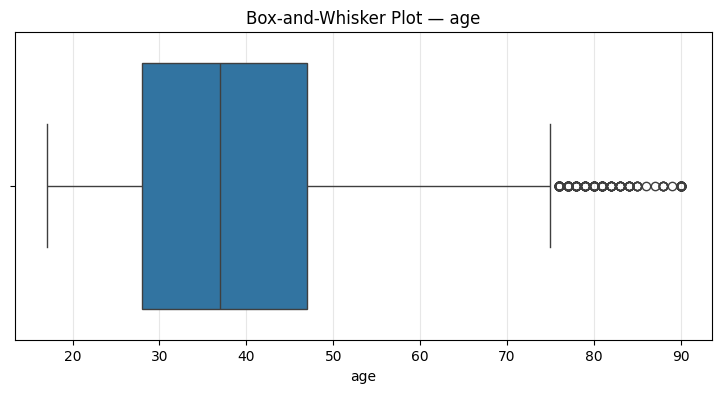

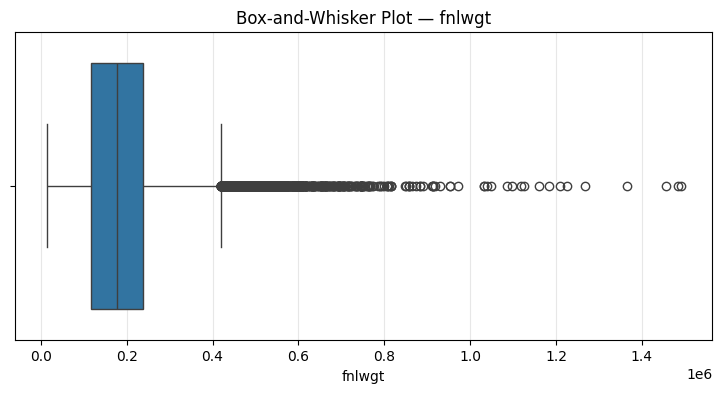

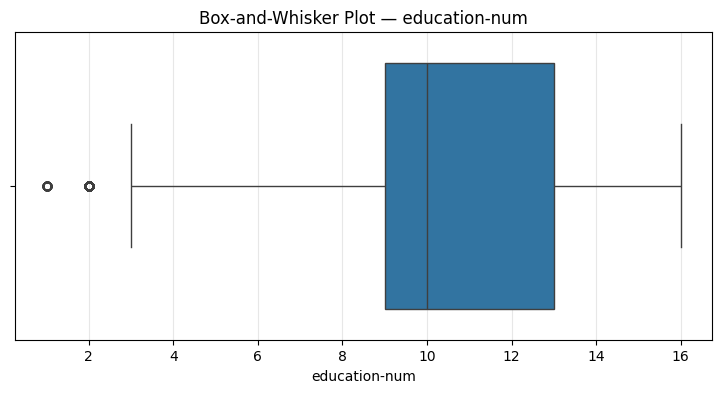

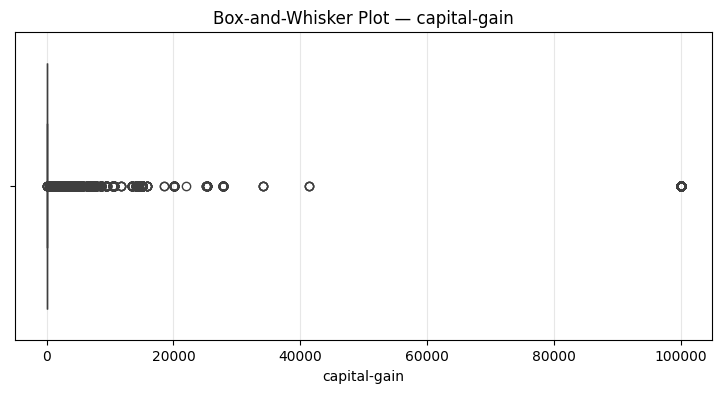

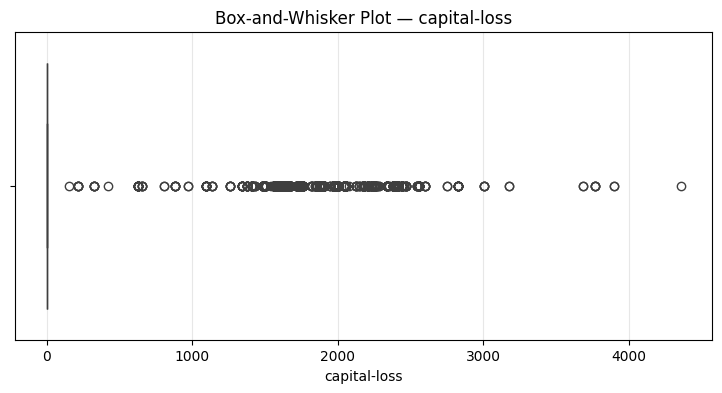

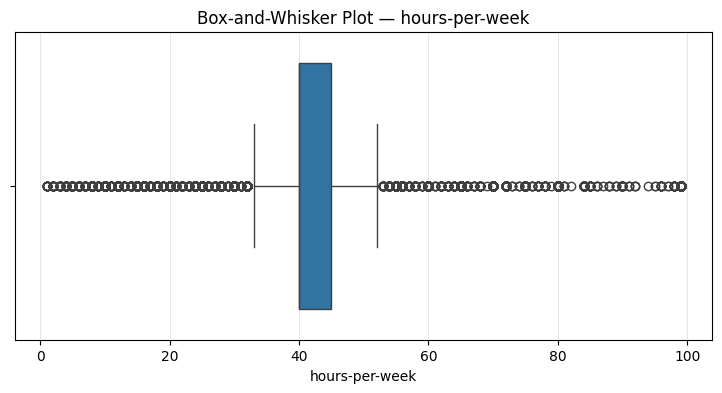

In [14]:
for column in numeric_columns:

    plt.figure(figsize=(9, 4))

    sns.boxplot(
        data=df,
        x=column
    )

    plt.title(
        f"Box-and-Whisker Plot - {column}"
    )

    plt.xlabel(column)
    plt.grid(
        True,
        axis="x",
        alpha=0.3
    )

    plt.show()

#### Correlation coefficient (r)

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
age,1.0000,-0.0756,0.0373,0.0796,0.0593,0.1016
fnlwgt,-0.0756,1.0000,-0.0420,-0.0041,-0.0044,-0.0187
education-num,0.0373,-0.0420,1.0000,0.1270,0.0817,0.1465
capital-gain,0.0796,-0.0041,0.1270,1.0000,-0.0321,0.0839
capital-loss,0.0593,-0.0044,0.0817,-0.0321,1.0000,0.0541
hours-per-week,0.1016,-0.0187,0.1465,0.0839,0.0541,1.0000


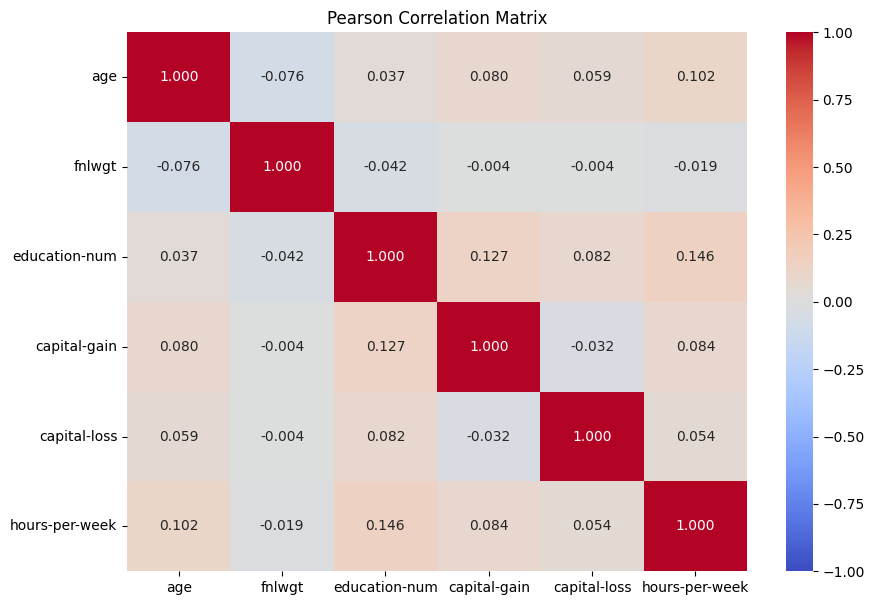

In [15]:

# Correlation matrix
correlation_matrix = df[numeric_columns].corr(method="pearson")

display(correlation_matrix.round(4))

# Correlation heatmap

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)

plt.title("Pearson Correlation Matrix")
plt.show()

# Handling outliers

The z-score and IQR methods found very different numbers of outliers, so we handled each variable separately:

- capital-gain, capital-loss: over 90% of the values are 0, so IQR marks every non-zero value as an outlier. The values are real, so we kept them and added a log(1 + x) version.
- age, hours-per-week: the high values are possible (age 90, 99 hours per week), so we didn't delete rows. We capped the values at the 1st and 99th percentile.
- education-num: the low values are real, so we kept them.
- fnlwgt: this is a census weight, not information about the person. It is dropped in the encoding, so we didn't handle it.

The new values are saved in new columns, the original columns are not changed.

#### Capping age and hours-per-week

In [16]:
# 1st and 99th percentile of age
age_low = df["age"].quantile(0.01)
age_high = df["age"].quantile(0.99)

df["age-capped"] = df["age"].clip(age_low, age_high)

print("age capped to:", age_low, "-", age_high)
print("Values changed:", (df["age"] != df["age-capped"]).sum())

# 1st and 99th percentile of hours-per-week
hours_low = df["hours-per-week"].quantile(0.01)
hours_high = df["hours-per-week"].quantile(0.99)

df["hours-per-week-capped"] = df["hours-per-week"].clip(hours_low, hours_high)

print("\nhours-per-week capped to:", hours_low, "-", hours_high)
print("Values changed:", (df["hours-per-week"] != df["hours-per-week-capped"]).sum())

age capped to: 17.0 - 73.0
Values changed: 380

hours-per-week capped to: 10.0 - 80.0
Values changed: 741


#### Log transformation of capital-gain and capital-loss

In [17]:
df["capital-gain-log"] = np.log1p(df["capital-gain"])
df["capital-loss-log"] = np.log1p(df["capital-loss"])

print("Skewness before and after the log transformation:")
print("capital-gain:", round(df["capital-gain"].skew(), 2), "->", round(df["capital-gain-log"].skew(), 2))
print("capital-loss:", round(df["capital-loss"].skew(), 2), "->", round(df["capital-loss-log"].skew(), 2))

Skewness before and after the log transformation:
capital-gain: 11.78 -> 3.08
capital-loss: 4.51 -> 4.27


#### Boxplots after handling the outliers

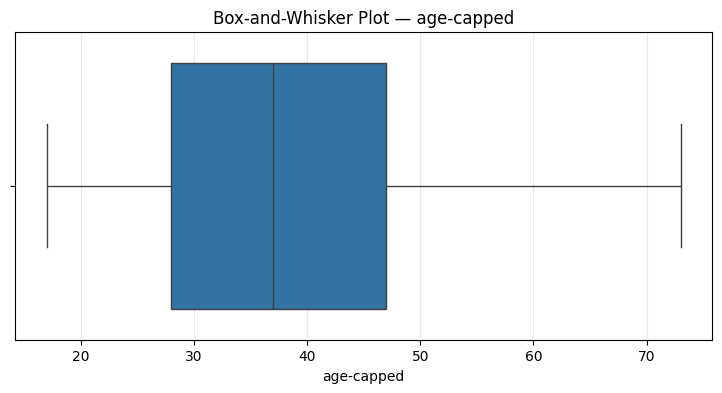

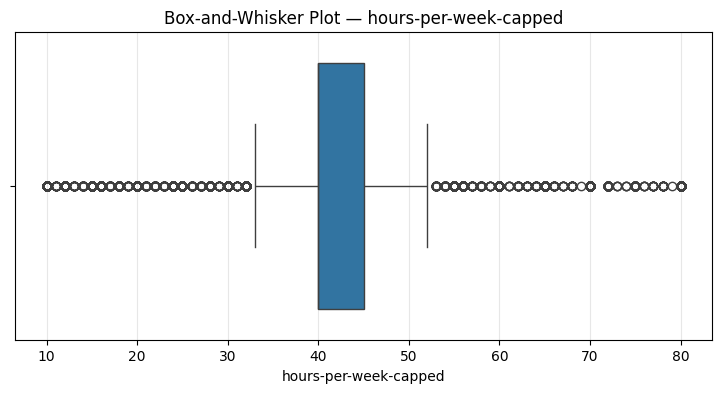

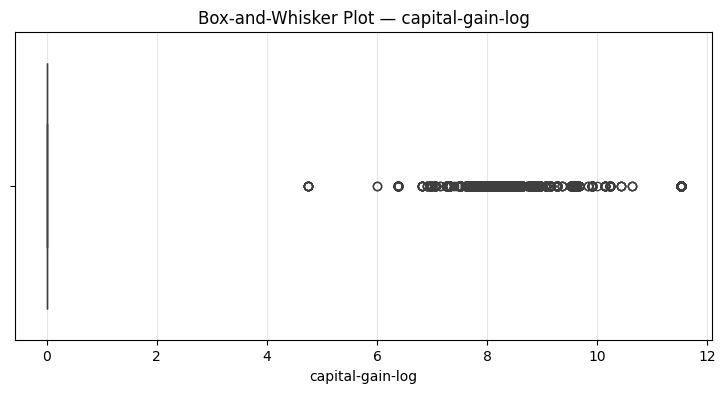

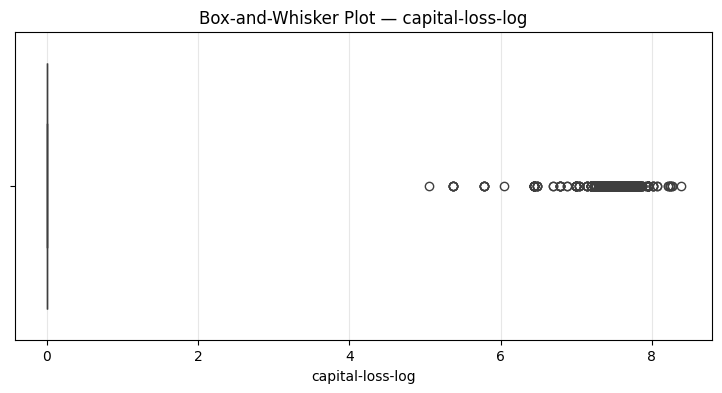

In [18]:
handled_columns = [
    "age-capped",
    "hours-per-week-capped",
    "capital-gain-log",
    "capital-loss-log"
]

for column in handled_columns:

    plt.figure(figsize=(9, 4))

    sns.boxplot(
        data=df,
        x=column
    )

    plt.title(
        f"Box-and-Whisker Plot - {column}"
    )

    plt.xlabel(column)
    plt.grid(
        True,
        axis="x",
        alpha=0.3
    )

    plt.show()

# Feature engineering

New features:

- `capital-net`: capital gain minus capital loss
- `has-capital`: 1 if the person has any capital gain or loss, otherwise 0
- `age-group`: 17-24, 25-34, 35-44, 45-54, 55-64, 65+
- `hours-category`: Part-time (under 35 h), Full-time (35-40 h), Overtime (over 40 h)
- `is-married`: 1 if `Married-civ-spouse` or `Married-AF-spouse`, otherwise 0

In [19]:
df["capital-net"] = df["capital-gain"] - df["capital-loss"]

df["has-capital"] = ((df["capital-gain"] > 0) | (df["capital-loss"] > 0)).astype(int)

df["is-married"] = df["marital-status"].isin(["Married-civ-spouse", "Married-AF-spouse"]).astype(int)

df["age-group"] = pd.cut(
    df["age"],
    bins=[16, 24, 34, 44, 54, 64, 100],
    labels=["17-24", "25-34", "35-44", "45-54", "55-64", "65+"]
)

df["hours-category"] = pd.cut(
    df["hours-per-week"],
    bins=[0, 34, 40, 100],
    labels=["Part-time", "Full-time", "Overtime"]
)

new_features = [
    "capital-net",
    "has-capital",
    "is-married",
    "age-group",
    "hours-category"
]

display(df[new_features].head(10))

,capital-net,has-capital,is-married,age-group,hours-category
0,2174,1,0,35-44,Full-time
1,0,0,1,45-54,Part-time
2,0,0,0,35-44,Full-time
3,0,0,1,45-54,Full-time
4,0,0,1,25-34,Full-time
5,0,0,1,35-44,Full-time
6,0,0,0,45-54,Part-time
7,0,0,1,45-54,Overtime
8,14084,1,0,25-34,Overtime
9,5178,1,1,35-44,Full-time


#### Frequency tables of the new categorical features

In [20]:
for column in ["has-capital", "is-married", "age-group", "hours-category"]:

    print("\n" + "=" * 60)
    print(f"{column}")
    print("=" * 60)

    frequency_table = df[column].value_counts().sort_index().to_frame(
        name="Frequency"
    )

    frequency_table["Percentage (%)"] = (
        frequency_table["Frequency"] / len(df) * 100
    )

    display(frequency_table.round(2))


has-capital


,Frequency,Percentage (%)
has-capital,,
0,39245,86.87
1,5930,13.13



is-married


,Frequency,Percentage (%)
is-married,,
0,24101,53.35
1,21074,46.65



age-group


,Frequency,Percentage (%)
age-group,,
17-24,7288,16.13
25-34,11924,26.40
35-44,11686,25.87
45-54,8405,18.61
55-64,4312,9.55
65+,1560,3.45



hours-category


,Frequency,Percentage (%)
hours-category,,
Part-time,7015,15.53
Full-time,24391,53.99
Overtime,13769,30.48


# Data Encoding

The `encode()` function:

- `sex`: 1 = Male, 0 = Female
- `native-country`: replaced by `is_us` (1 = United-States, 0 = other)
- `workclass`, `marital-status`, `occupation`, `relationship`, `race`: one-hot encoding with `drop_first=True`
- drops `education` (same information as `education-num`) and `fnlwgt` (census weight)
- drops `age`, `hours-per-week`, `capital-gain`, `capital-loss`, because we use the capped and log versions instead
- drops `capital-net`, `is-married`, `age-group`, `hours-category`, because they repeat information that is already in the data (we use them only for the analysis)
- `income` is kept separately as the target (1 = >50K)

In [21]:
def encode(data):
    data = data.copy()

    # Binary columns
    data["sex"] = (data["sex"] == "Male").astype(int)
    data["is_us"] = (data["native-country"] == "United-States").astype(int)

    # Drop columns not needed (education is covered by education-num)
    data = data.drop(columns=["education", "native-country", "fnlwgt", "income"],
                     errors="ignore")

    # Drop the original columns that were replaced by the outlier-handled versions
    data = data.drop(columns=["age", "hours-per-week", "capital-gain", "capital-loss"],
                     errors="ignore")

    # Drop the new features that repeat information already in the data
    data = data.drop(columns=["capital-net", "is-married", "age-group", "hours-category"],
                     errors="ignore")

    # One-hot encode the remaining text columns
    return pd.get_dummies(
        data,
        columns=["workclass", "marital-status", "occupation", "relationship", "race"],
        drop_first=True,
        dtype=int,
    )

In [22]:
df_encoded = encode(df)

# Target variable as 0/1: 1 = earns >50K
income = (df["income"] == ">50K").astype(int)

print("df_encoded shape:", df_encoded.shape)
print(df_encoded.dtypes.value_counts())   # should be all numbers, no 'object'/'str'
print("Missing values:", df_encoded.isna().sum().sum())
print("Non-numeric columns:", df_encoded.select_dtypes(exclude="number").columns.tolist())
print("Share earning >50K:", round(income.mean(), 3))

display(df_encoded.head())

df_encoded shape: (45175, 42)
int64      40
float64     2
Name: count, dtype: int64
Missing values: 0
Non-numeric columns: []
Share earning >50K: 0.248


,education-num,sex,age-capped,hours-per-week-capped,capital-gain-log,capital-loss-log,has-capital,is_us,workclass_Local-gov,workclass_Private,...,occupation_Transport-moving,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Asian-Pac-Islander,race_Black,race_Other,race_White
0,13,1,39,40,7.684784,0.0,1,1,0,0,...,0,1,0,0,0,0,0,0,0,1
1,13,1,50,13,0.000000,0.0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1
2,9,1,38,40,0.000000,0.0,0,1,0,1,...,0,1,0,0,0,0,0,0,0,1
3,7,1,53,40,0.000000,0.0,0,1,0,1,...,0,0,0,0,0,0,0,1,0,0
4,13,0,28,40,0.000000,0.0,0,0,0,1,...,0,0,0,0,0,1,0,1,0,0


# Standardization

The numerical columns have very different ranges, for example `age-capped` goes up to 73 and `capital-gain-log` only up to about 11.5. For k-means and DBSCAN this matters, because they use distances. So we standardized the numerical columns to mean 0 and standard deviation 1: z = (x - mean) / std.

The 0/1 columns are not standardized.

`df_scaled` is for clustering. For regression we will do the scaling again after the train/test split, only on the training data.

In [23]:
scale_columns = [
    "age-capped",
    "education-num",
    "hours-per-week-capped",
    "capital-gain-log",
    "capital-loss-log"
]

df_scaled = df_encoded.copy()

scaler = StandardScaler()
df_scaled[scale_columns] = scaler.fit_transform(df_scaled[scale_columns])

print("Before standardization:")
display(df_encoded[scale_columns].describe().T[["mean", "std", "min", "max"]].round(3))

print("After standardization:")
display(df_scaled[scale_columns].describe().T[["mean", "std", "min", "max"]].round(3))

Before standardization:


,mean,std,min,max
age-capped,38.505,13.060,17.0,73.000
education-num,10.119,2.552,1.0,16.000
hours-per-week-capped,40.900,11.566,10.0,80.000
capital-gain-log,0.742,2.468,0.0,11.513
capital-loss-log,0.356,1.597,0.0,8.380


After standardization:


,mean,std,min,max
age-capped,-0.0,1.0,-1.647,2.641
education-num,-0.0,1.0,-3.574,2.305
hours-per-week-capped,-0.0,1.0,-2.672,3.381
capital-gain-log,-0.0,1.0,-0.300,4.365
capital-loss-log,0.0,1.0,-0.223,5.025


# Exploratory data analysis

#### Share of people earning >50K in each group

The red line shows the share for the whole dataset.

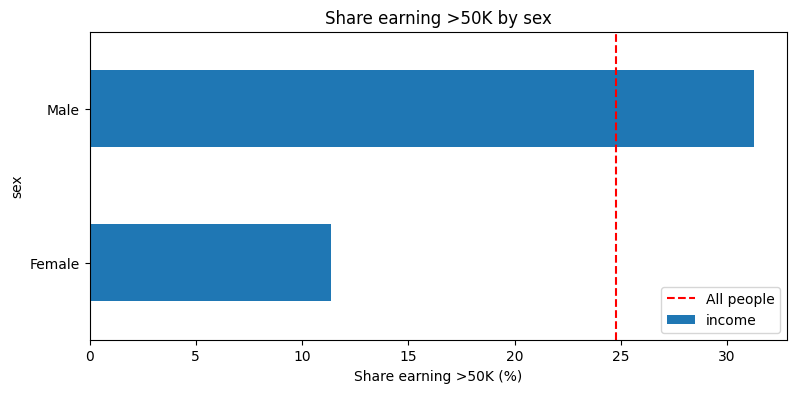

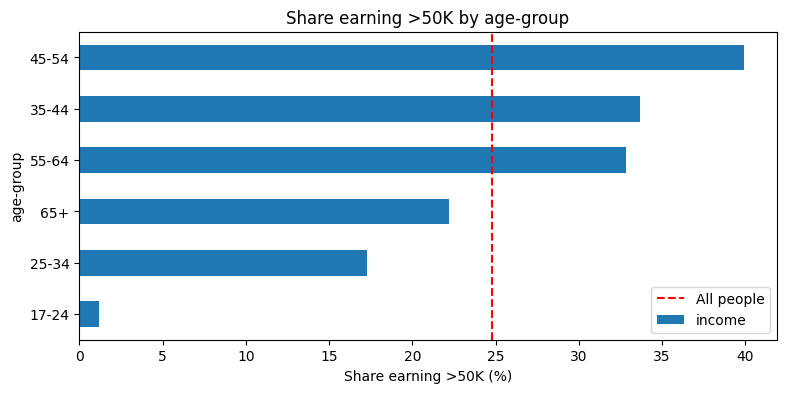

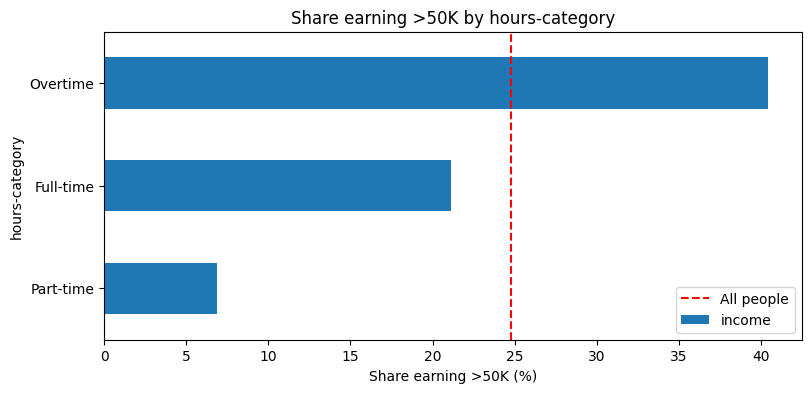

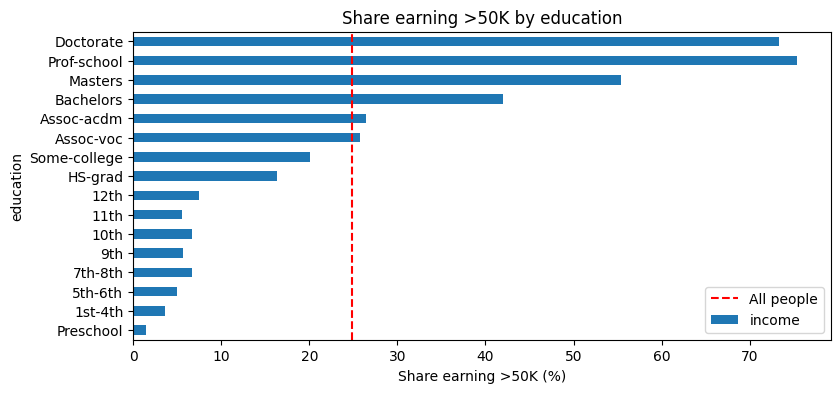

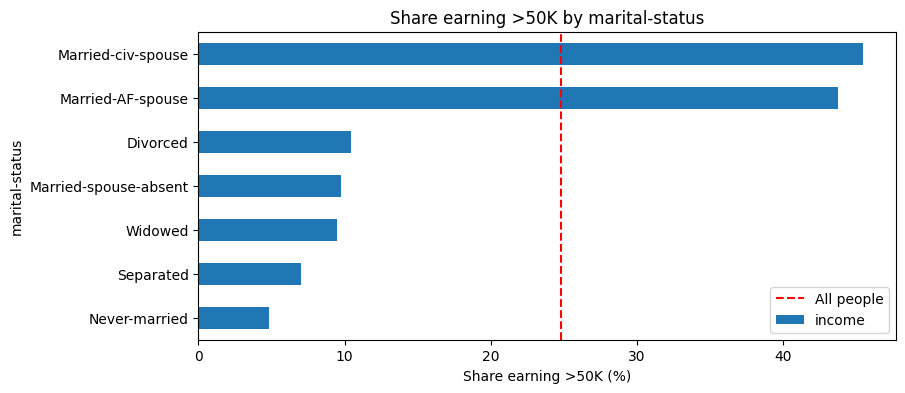

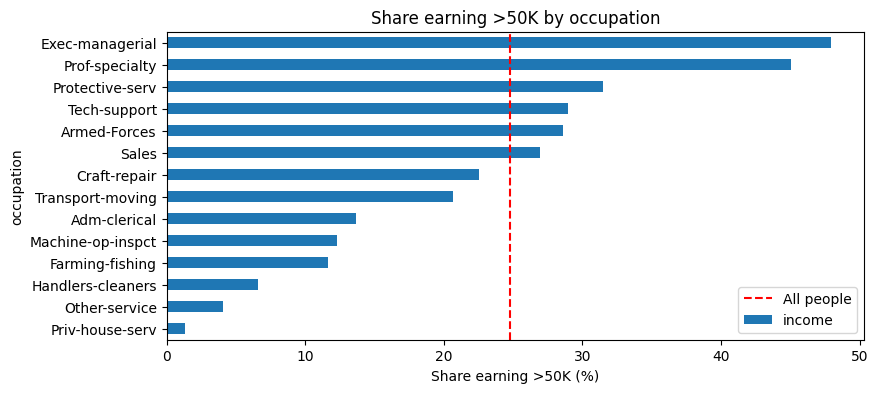

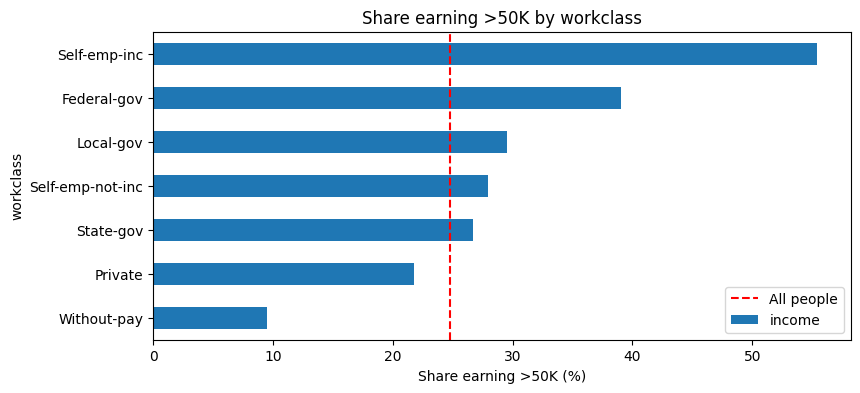

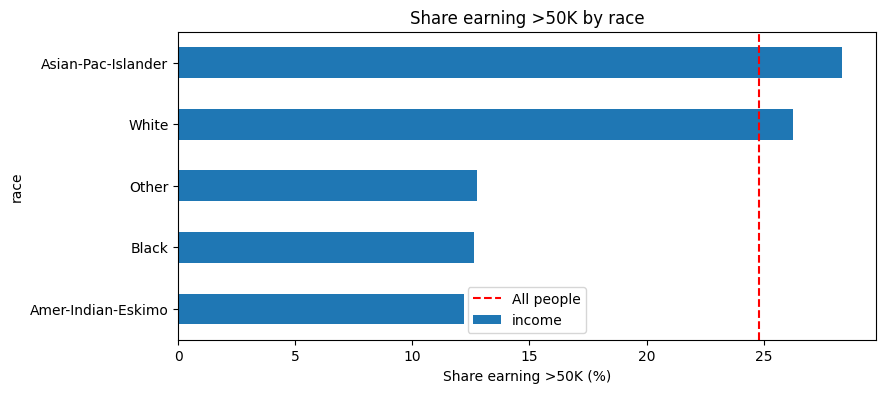

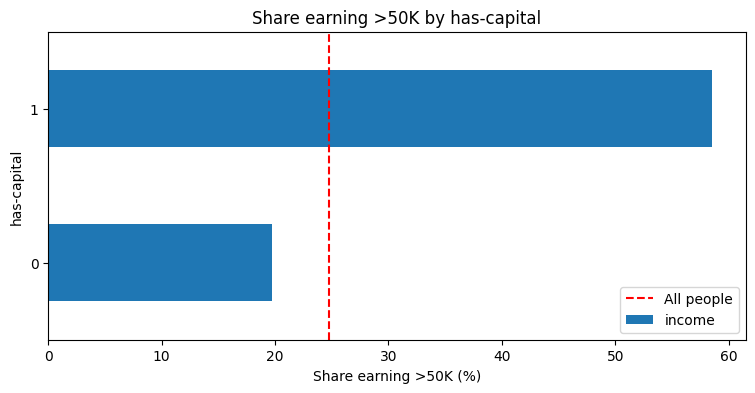

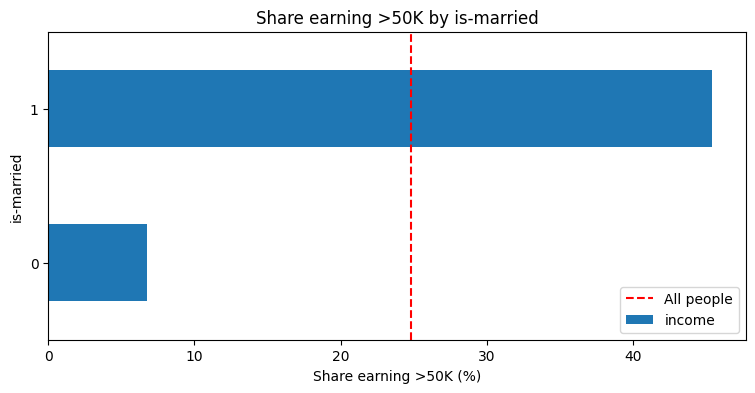

In [24]:
group_columns = [
    "sex",
    "age-group",
    "hours-category",
    "education",
    "marital-status",
    "occupation",
    "workclass",
    "race",
    "has-capital",
    "is-married"
]

overall_share = (df["income"] == ">50K").mean() * 100

for column in group_columns:

    share = (df["income"] == ">50K").groupby(df[column], observed=True).mean() * 100

    # Education is shown in the order of the education level, the rest from lowest to highest share
    if column == "education":
        order = df.groupby("education")["education-num"].first().sort_values().index
        share = share.reindex(order)
    else:
        share = share.sort_values()

    plt.figure(figsize=(9, 4))
    share.plot.barh()
    plt.axvline(overall_share, color="red", linestyle="--", label="All people")
    plt.xlabel("Share earning >50K (%)")
    plt.title(f"Share earning >50K by {column}")
    plt.legend()
    plt.show()

### Correlation of the encoded variables with income

The Pearson correlation of every encoded column with `income` (1 = earns >50K).

,Correlation with income
marital-status_Never-married,-0.3193
relationship_Own-child,-0.2226
relationship_Not-in-family,-0.1953
occupation_Other-service,-0.1655
relationship_Unmarried,-0.1474
workclass_Private,-0.1167
occupation_Handlers-cleaners,-0.0917
race_Black,-0.0905
relationship_Other-relative,-0.0857
occupation_Machine-op-inspct,-0.0768


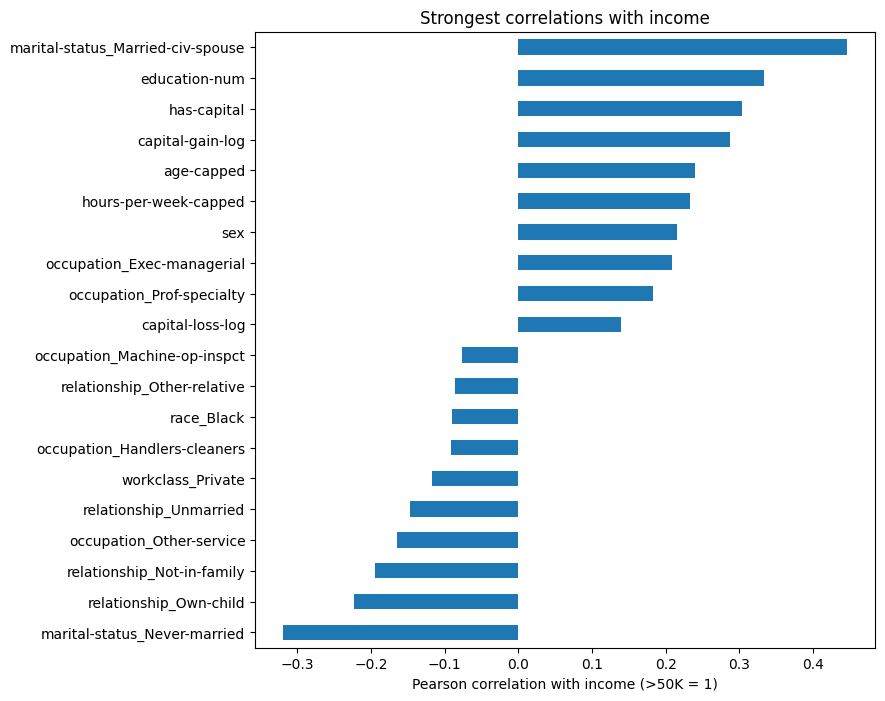

In [25]:
income_correlation = df_encoded.corrwith(income).sort_values()

display(income_correlation.round(4).to_frame("Correlation with income"))

# The 10 strongest negative and the 10 strongest positive correlations
strongest = pd.concat([income_correlation.head(10), income_correlation.tail(10)])

plt.figure(figsize=(8, 8))
strongest.plot.barh()
plt.xlabel("Pearson correlation with income (>50K = 1)")
plt.title("Strongest correlations with income")
plt.show()

# Save the cleaned data

- `adult_clean.csv`: cleaned data with the original categories, the capped/log columns and the new features
- `adult_encoded.csv`: encoded data, `income` as 0/1
- `adult_scaled.csv`: encoded and standardized data, `income` as 0/1 (for clustering)

In [26]:
os.makedirs("cleaned_data", exist_ok=True)

df.to_csv("cleaned_data/adult_clean.csv", index=False)

df_encoded_with_income = df_encoded.copy()
df_encoded_with_income["income"] = income
df_encoded_with_income.to_csv("cleaned_data/adult_encoded.csv", index=False)

df_scaled_with_income = df_scaled.copy()
df_scaled_with_income["income"] = income
df_scaled_with_income.to_csv("cleaned_data/adult_scaled.csv", index=False)

print("Saved cleaned_data/adult_clean.csv:", df.shape)
print("Saved cleaned_data/adult_encoded.csv:", df_encoded_with_income.shape)
print("Saved cleaned_data/adult_scaled.csv:", df_scaled_with_income.shape)

Saved cleaned_data/adult_clean.csv: (45175, 24)
Saved cleaned_data/adult_encoded.csv: (45175, 43)
Saved cleaned_data/adult_scaled.csv: (45175, 43)


# Summary

### Dataset
Adult Income (`adult.data` and `adult.test` together): 48,842 rows, 15 variables (6 numerical, 9 categorical). The target is `income` (>50K or <=50K).

### Data cleaning
- Removed the dot from the income labels in the test file (`>50K.`).
- Deleted 3,620 rows with missing values (7.41%), they were only in `workclass`, `occupation` and `native-country`.
- Deleted 47 duplicate rows.
- 45,175 rows are left. 24.8% of people earn more than 50K, so the classes are imbalanced.

### Outliers
z-score and IQR gave very different results because some variables are very skewed. We didn't delete any rows:
- `age` and `hours-per-week` capped at the 1st and 99th percentile (17-73 years, 10-80 hours).
- `capital-gain` and `capital-loss` log-transformed. The skewness of `capital-gain` went from 11.78 to 3.08, but `capital-loss` is still skewed (4.27) because almost all values are 0.

### Feature engineering
`capital-net`, `has-capital`, `is-married`, `age-group`, `hours-category` and `is_us`.

### Encoding and standardization
`sex` and `native-country` became 0/1 columns, the other categorical variables were one-hot encoded (42 columns in total). The numerical columns were standardized.

## Findings
- The numerical variables are only weakly correlated with each other (all below 0.15).
- Strongest correlations with income: `Married-civ-spouse` (0.45), `education-num` (0.33), `has-capital` (0.30), `capital-gain-log` (0.29), age (0.24). Strongest negative: `Never-married` (-0.32) and `Own-child` (-0.22).
- 45.4% of married people earn more than 50K, but only 6.8% of the others.
- People with capital gains or losses: 58.6% earn more than 50K, the rest: 19.7%.
- High income gets more common with age until 45-54 (39.9%), then it drops. Only 1.2% of people aged 17-24 earn more than 50K.
- Overtime: 40.4% earn more than 50K, part-time: 6.9%.